In [1]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs
import cftime

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

In [7]:
zoom_select = 6

shield_cat = intake.open_catalog("/home/tmerlis/hackathon/xsh24_scream_main.yaml")["xsh24_coarse"]
shield = shield_cat(zoom=zoom_select).to_dask()
shield = shield.drop_vars("cell")
shield = shield.pipe(egh.attach_coords)

online_cat = intake.open_catalog("https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml")["online"]
print(list(online_cat))

cru_cat = intake.open_catalog("/home/cs3554/CERES.yaml")["CERES_Cru23"]
ceres = cru_cat(zoom=zoom_select).to_dask()
ceres = ceres.pipe(egh.attach_coords)

shield

/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


['CERES_EBAF', 'ERA5', 'IR_IMERG', 'JRA3Q', 'MERRA2', 'casesm2_10km_nocumulus', 'icon_d3hp003', 'icon_d3hp003aug', 'icon_d3hp003feb', 'icon_ngc4008', 'ifs_tco3999-ng5_deepoff', 'ifs_tco3999-ng5_rcbmf', 'ifs_tco3999-ng5_rcbmf_cf', 'nicam_gl11', 'scream-dkrz', 'tracking-d3hp003', 'um_Africa_km4p4_RAL3P3_n1280_GAL9_nest', 'um_CTC_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SAmer_km4p4_RAL3P3_n1280_GAL9_nest', 'um_SEA_km4p4_RAL3P3_n1280_GAL9_nest', 'um_glm_n1280_CoMA9_TBv1p2', 'um_glm_n1280_GAL9', 'um_glm_n2560_RAL3p3']


/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),
/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


<xarray.Dataset> Size: 249GB
Dimensions:  (time: 3560, cell: 49152, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat      (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon      (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Data variables: (12/38)
    clivi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clt      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clwvi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hflsd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hfssd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hur      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    ...       ...
    uas      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    va       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    vas      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    wa       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    wap      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    zg       (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>

In [8]:
ceres

<xarray.Dataset> Size: 399MB
Dimensions:      (time: 289, cell: 49152)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2000-03-15 2000-04-15 ... 2024-03-15
    crs          int64 8B 0
  * cell         (cell) int64 393kB 0 1 2 3 4 ... 49147 49148 49149 49150 49151
    lat          (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -0.5968
    lon          (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Data variables:
    F_TOA        (time, cell) float32 57MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_TOA_clr_c  (time, cell) float32 57MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_TOA_clr_t  (time, cell) float32 57MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_cloud      (time, cell) float32 57MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_clr        (time, cell) float32 57MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_surf       (time, cell) float32 57MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    S            (time, cell) float32 57MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    DOI:          10.5067/TERRA-AQUA-NOAA20/CERES/EBAF_L3B004.2
    comment:      Climatology from 07/2005 to 06/2015
    institution:  NASA Langley Research Center
    title:        CERES EBAF TOA and Surface Fluxes. Monthly Averages and 07/...
    version:      Edition 4.2; Revised data Release Date January 2, 2024

In [11]:
def calc_atm(F_TOA_up, S, F_surf_dn, F_surf_up):
    S_m = np.ma.masked_less(S, 1e-9)
    F_surf_dn_m = np.ma.masked_less(F_surf_dn, 1e-9)
    R = F_TOA_up / S_m
    T = F_surf_dn / S_m
    a = F_surf_up / F_surf_dn_m
    t = T * (1 - a * R) / (1 - a**2 * T**2)
    r = R - t * a * T
    F_atm = np.where(S_m.mask | F_surf_dn_m.mask, 0, S * r)
    return F_atm

def calc_surf(F_TOA_up, S, F_surf_dn, F_surf_up):
    S_m = np.ma.masked_less(S, 1e-9)
    F_surf_dn_m = np.ma.masked_less(F_surf_dn, 1e-9)
    R = F_TOA_up / S_m
    T = F_surf_dn / S_m
    a = F_surf_up / F_surf_dn_m
    t = T * (1 - a * R) / (1 - a**2 * T**2)
    r = R - t * a * T
    F_surf = np.where(S_m.mask | F_surf_dn_m.mask, 0, S * (a * t**2) / (1 - r * a))
    return F_surf

def do_Crueger23_decomp(ds):

    ds["F_atm"] = xr.apply_ufunc(
        calc_atm, 
        ds.rsut, 
        ds.rsdt, 
        ds.rsds, 
        ds.rsus,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["F_surf"] = xr.apply_ufunc(
        calc_surf, 
        ds.rsut, 
        ds.rsdt, 
        ds.rsds, 
        ds.rsus,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["G_atm"] = xr.apply_ufunc(
        calc_atm, 
        ds.rsutcs, 
        ds.rsdt, 
        ds.rsdscs, 
        ds.rsuscs,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["G_surf"] = xr.apply_ufunc(
        calc_surf, 
        ds.rsutcs, 
        ds.rsdt, 
        ds.rsdscs, 
        ds.rsuscs,
        vectorize=True,
        output_dtypes=[ds.rsdt.dtype],
        dask="allowed"
    )

    ds["gamma"] = ds.F_surf / ds.G_surf # attenuation of surface contribution by clouds
    ds["gamma"] = xr.where(ds.gamma < 1, 1, ds.gamma).fillna(0) # attenuation factor cannot be smaller than 1 because 1 means no attenuation. also if the clear-sky surface contribution is zero it is undefined, so fill as zero.
    ds["F_clr"] = (ds.gamma * ds.G_atm).fillna(0) # assume attenuation of surface by clouds is same as attenuation of atmosphere by clouds (implicitly, assumes that aerosols are below clouds)
    ds["F_clr"] = xr.where(ds.F_clr > ds.F_atm, ds.F_atm, ds.F_clr) # F_clr can't be larger than total atm component
    ds["F_cloud"] = ds.F_atm - ds.F_clr
    ds["F_TOA"] = ds.rsut

    return ds

In [12]:
shield_Cru23 = do_Crueger23_decomp(shield)
shield_Cru23

<xarray.Dataset> Size: 255GB
Dimensions:  (time: 3560, cell: 49152, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 393kB 0 1 2 3 4 5 ... 49147 49148 49149 49150 49151
    lat      (cell) float64 393kB 0.5968 1.194 1.194 ... -1.194 -1.194 -0.5968
    lon      (cell) float64 393kB 45.0 45.7 44.3 45.0 ... 315.7 314.3 315.0
Data variables: (12/46)
    clivi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clt      (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    clwvi    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hflsd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hfssd    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    hur      (time, plev, cell) float32 22GB dask.array<chunksize=(24, 31, 49152), meta=np.ndarray>
    ...       ...
    G_atm    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    G_surf   (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    gamma    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_clr    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_cloud  (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>
    F_TOA    (time, cell) float32 700MB dask.array<chunksize=(24, 49152), meta=np.ndarray>

In [14]:
def worldmap(var, **kwargs):
    projection = ccrs.Robinson(central_longitude=-135.5808361)
    fig, ax = plt.subplots(
        figsize=(8, 4), subplot_kw={"projection": projection}, constrained_layout=True
    )
    ax.set_global()

    hpshow = egh.healpix_show(var, ax=ax, **kwargs)
    cbar = plt.colorbar(hpshow, ax=ax, orientation='vertical', 
                    pad=0.05, shrink=0.8)
    # fails when cartopy tries to download 
    # ax.add_feature(cf.COASTLINE, linewidth=0.8)
    # ax.add_feature(cf.BORDERS, linewidth=0.4)

In [24]:
# shield_Cru23_clim = shield_Cru23.groupby("time.month").mean("time")
shield_Cru23_clim = shield_Cru23
ceres_clim = ceres.groupby("time.month").mean("time")

Text(0.5, 1.0, 'F_surf XSHiELD-CERES')

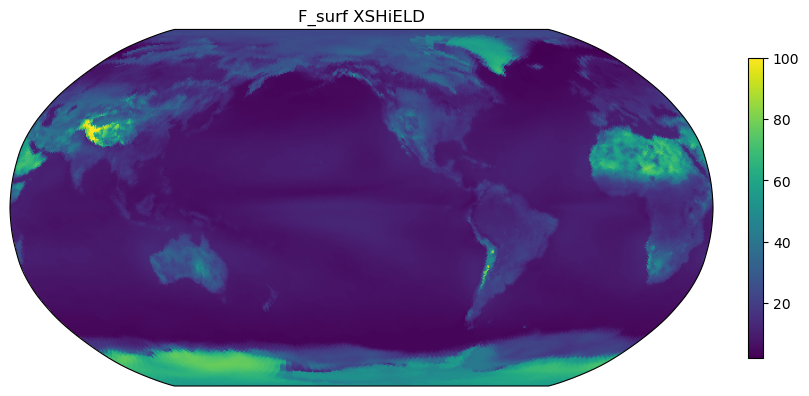

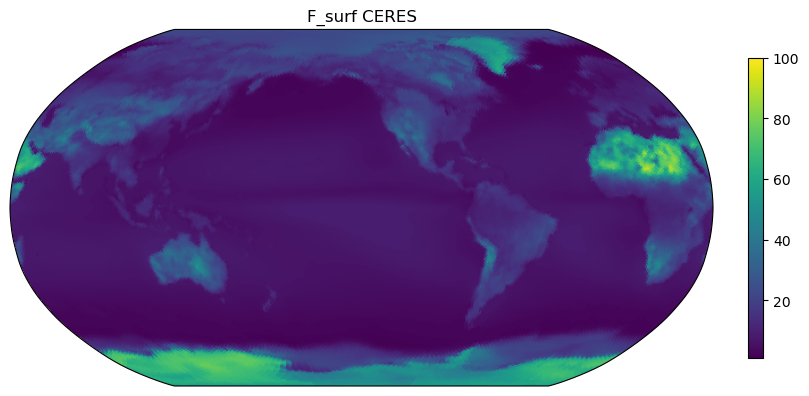

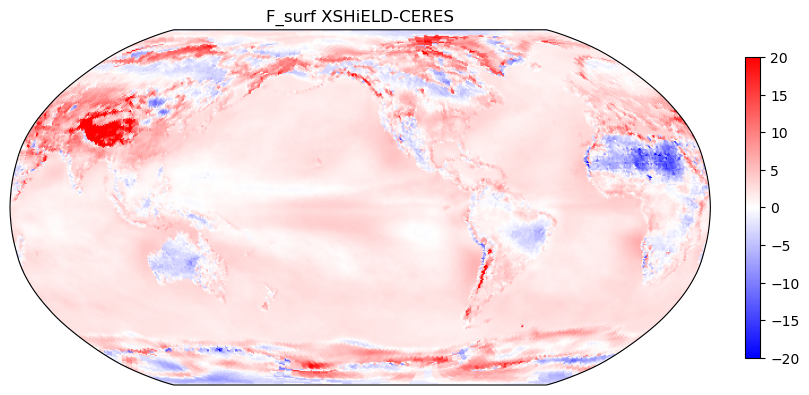

In [26]:
var = "F_surf"

worldmap(shield_Cru23_clim[var].mean(dim="month"), vmax=60)
plt.title(var+" XSHiELD")

worldmap(ceres_clim[var].mean(dim="month"), vmax=60)
plt.title(var+" CERES")

worldmap((shield_Cru23_clim[var] - ceres_clim[var]).mean(dim="month"), cmap="bwr", vmin=-20, vmax=20)
plt.title(var+" XSHiELD-CERES")

Text(0.5, 1.0, 'F_clr XSHiELD-CERES')

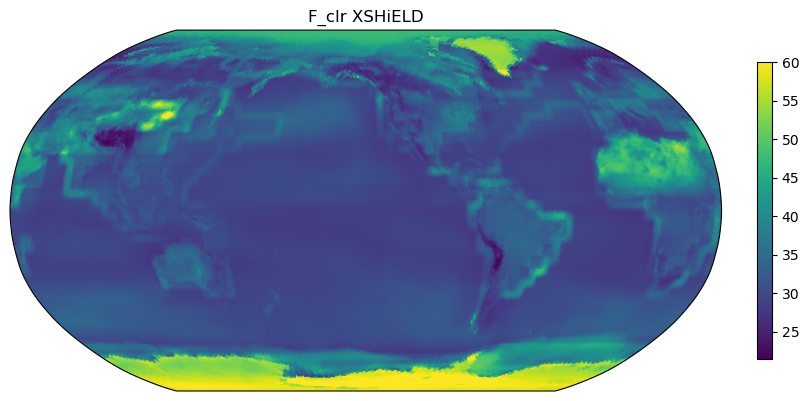

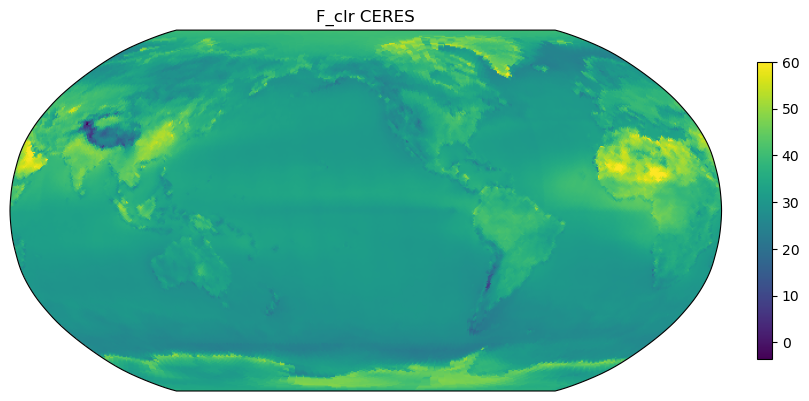

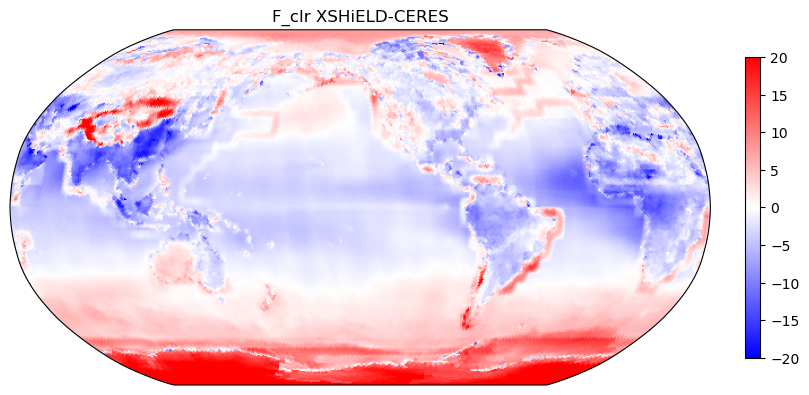

In [28]:
var = "F_clr"

worldmap(shield_Cru23_clim[var].mean(dim="month"), vmax=60)
plt.title(var+" XSHiELD")

worldmap(ceres_clim[var].mean(dim="month"), vmax=60)
plt.title(var+" CERES")

worldmap((shield_Cru23_clim[var] - ceres_clim[var]).mean(dim="month"), cmap="bwr", vmin=-20, vmax=20)
plt.title(var+" XSHiELD-CERES")

Text(0.5, 1.0, 'F_cloud XSHiELD-CERES')

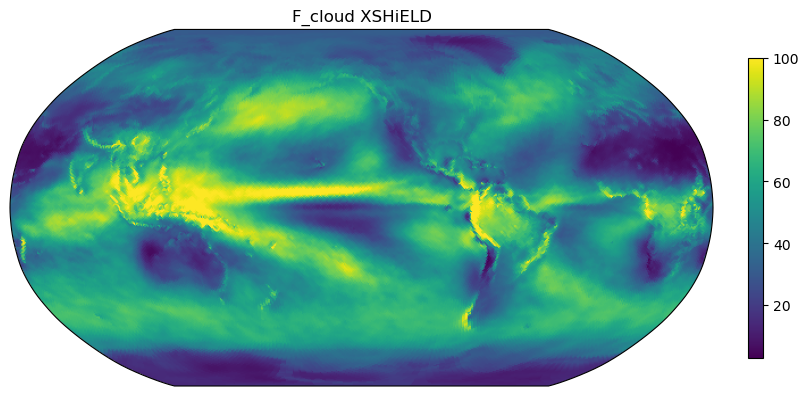

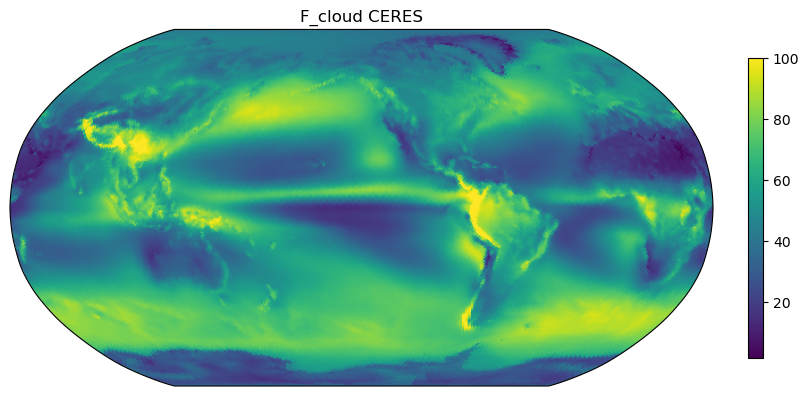

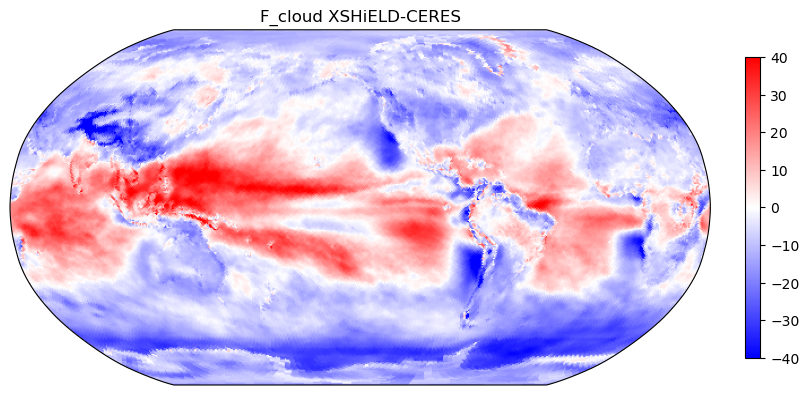

In [29]:
var = "F_cloud"

worldmap(shield_Cru23_clim[var].mean(dim="month"), vmax=100)
plt.title(var+" XSHiELD")

worldmap(ceres_clim[var].mean(dim="month"), vmax=100)
plt.title(var+" CERES")

worldmap((shield_Cru23_clim[var] - ceres_clim[var]).mean(dim="month"), cmap="bwr", vmin=-40, vmax=40)
plt.title(var+" XSHiELD-CERES")